In [1]:
import numpy as np
import math
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
import operator as op
from functools import reduce

In [2]:
def ncr(n, r):
    r = min(r, n-r)
    numer = reduce(op.mul, range(n, n-r, -1), 1)
    denom = reduce(op.mul, range(1, r+1), 1)
    return numer // denom  # or / in Python 2

In [3]:
#define the shape of the environment (i.e., its states). States for each node are 0,1,2,...,m_star where
# 0 = inactive memory, 1 to m_star = active memory
m_star = 3  #number of states = m_star + 1
n_node = 4 #number of nodes
state = np.zeros([n_node, n_node])
n_state = (m_star+1)**(ncr(n_node,2))
n_action = (2)**(2*n_node - 1)
# 0 = wait for photon/BM, 1 = request for photon/BM (on nodes we do BM, on physical links entangled pair request)
action = np.zeros([n_node, n_node])

q_values = np.zeros([n_state,n_action])

In [4]:
#check if is an allowed state
def is_allowed_state(state,n_node,m_star):
    allowed = True

    for i in range(n_node):
        if state[i][i]>0:
            allowed = False
            break
            
        c1 = 0
        for j in range(i,n_node):
            if state[i][j]>0:
                c1+=1
        if c1>1:
            allowed = False
            break
            
    if allowed:
        for j in range(n_node):
            c2 = 0
            for i in range(j):
                if state[i][j]>0:
                    c2+=1
            if c2>1:
                allowed = False
                break
                
    if allowed:
        for i in range(n_node):
            for j in range(i+2, n_node):
                if state[i][j] > 0 and allowed:
                    if state[i][i+1]>0 or state[i][j-1]:
                        allowed = False
                    
                    for k in range(i+1,j):
                        if allowed==False:
                            break
                        for l in range(j+1,n_node):
                            if state[k][l]>0:
                                allowed=False
                                break
                        
                if not allowed:
                    break
            if not allowed:
                break
                
    return(allowed)   

# check if allowed action
def is_allowed_action(action,n_node,m_star):
    allowed = True
    
    if action[0][0] == 1 or action[n_node-1][n_node-1] == 1:
        return False
    
    for i in range(1,n_node-1):
            if action[i][i]>0:
                if action[i-1][i]==1 or action[i][i+1]==1:
                    allowed = False
                    break
                    
    if allowed:
        for i in range(n_node):
            for j in range(i+2,n_node):
                if action[i][j]>0:
                    allowed = False
                    break
            if not allowed:
                break
    
    return allowed                           

In [5]:
# Train the Model
# Our next task is for our AI agent to learn about its environment by implementing a Q-learning model. 
# The learning process will follow these steps:
# Choose a random, non-terminal state for the agent to begin this new episode.
# Choose an action for the current state. Actions will be chosen using an epsilon greedy algorithm. 
# This algorithm will usually choose the most promising action for the AI agent, 
# but it will occasionally choose a less promising option in order to encourage the agent to explore the environment.
# Perform the chosen action, and transition to the next state (i.e., move to the next location).
# Receive the reward for moving to the new state, and calculate the temporal difference.
# Update the Q-value for the previous state and action pair.
# If the new (current) state is a terminal state, go to #1. Else, go to #2.
# This entire process will be repeated across 1000 episodes. 
# This will provide the AI agent sufficient opportunity to learn the shortest paths 
# Define Helper Functions


#define a function that determines if the specified location is a terminal state
def is_terminal_state(current_state,n_node,m_star):
  #if the state has a link between 1st and last node then it is terminal
    if current_state[0][n_node-1] > 0 and is_allowed_state(current_state,n_node,m_star):  
        return True
    else:
        return False
    
def get_state_index(state,n_node,m_star):
    index = 0
    n_max = ncr(n_node,2) #total number of links (physical + virtual)
    n = 0
    for i in range(n_node):
        for j in range(i+1,n_node):
            n = n+1
            index = index + state[i][j]*(m_star+1)**(n_max - n)
    return int(index)

def get_state_from_index(index,n_node,m_star):
    base = m_star+1
    base_num = ""
    while index>0:
        dig = int(index%base)
        base_num += str(dig)
        index //= base
    base_num = base_num[::-1]
    a = np.zeros([ncr(n_node,2)])
    pad = ncr(n_node,2)-len(base_num)
    for k in range(ncr(n_node,2)):
        if k < pad:
            a[k] = 0
        else:
            a[k] = int(base_num[k-pad])
            
    state = np.zeros([n_node,n_node])
    k = 0
    for i in range(n_node):
        for j in range(i+1,n_node):
            k = k + 1
            state[i][j] = a[k-1]
            state[j][i] = state[i][j]
            
    return state

def get_action_index(state,n_node,m_star):
    index = 0
    n_max = 2*n_node - 1 #total number of physical links + number of nodes
    n = 0
    for i in range(n_node):
        for j in range(i,i+2):
            if j<n_node:
                n = n+1
                index = index + state[i][j]*(2)**(n_max - n)
    return int(index)

def get_action_from_index(index,n_node,m_star):
    base = 2
    base_num = ""
    while index>0:
        dig = int(index%base)
        base_num += str(dig)
        index //= base
    base_num = base_num[::-1]
    
    a = np.zeros([2*n_node - 1])
    pad = 2*n_node - 1 - len(base_num)
    for k in range(2*n_node - 1):
        if k < pad:
            a[k] = 0
        else:
            a[k] = int(base_num[k-pad])
            
    action = np.zeros([n_node,n_node])
    k = 0
    for i in range(n_node):
        for j in range(i,i+2):
            if j<n_node:
                k = k + 1
                action[i][j] = a[k-1]
                action[j][i] = action[i][j]
            
    return action

ct=0
cta=0
allowed_states = []
allowed_actions = []
for i in range(n_state):
    if is_allowed_state(get_state_from_index(i,n_node,m_star),n_node,m_star):
        ct+=1
        allowed_states.append(i)       

for i in range(n_action):
    if is_allowed_action(get_action_from_index(i,n_node,m_star),n_node,m_star):
        cta+=1
        allowed_actions.append(i)       
allowed_states = np.array(allowed_states)
allowed_actions = np.array(allowed_actions)

#q_values = np.zeros([ct,cta])
print([ct,cta])
def get_random_state(n_node,m_star,allowed_states,allowed_actions):
    i = np.random.randint(0,ct)
    return get_state_from_index(allowed_states[i],n_node,m_star)

def get_random_action(n_node,m_star,allowed_states,allowed_actions):
    i = np.random.randint(0,cta)
    return get_action_from_index(allowed_actions[i],n_node,m_star)

#define a function that will choose a random, non-terminal starting state
def get_starting_state(n_node,m_star,allowed_states,allowed_actions):
    
#   get a random state
    current_state = get_random_state(n_node,m_star,allowed_states,allowed_actions)

#   continue choosing random state until a non-terminal state is identified
    while is_terminal_state(current_state,n_node,m_star):
        current_state = get_random_state(n_node,m_star,allowed_states,allowed_actions)

    return current_state


#define an epsilon greedy algorithm that will choose which action to take next
def get_next_action(current_state, epsilon,n_node,m_star,q_values,allowed_states,allowed_actions):
  #if a randomly chosen value between 0 and 1 is less than epsilon, 
  #then choose the most promising value from the Q-table for this state.
    state_index = get_state_index(current_state,n_node,m_star)
    
    if np.random.random() < epsilon:
        action_index = np.argmax(q_values[state_index])
        opt_action = get_action_from_index(action_index,n_node,m_star)
        #return opt_action
        if is_allowed_action(opt_action,n_node,m_star): 
            return opt_action
        else:
            return get_random_action(n_node,m_star,allowed_states,allowed_actions)
    else: #choose a random action
        return get_random_action(n_node,m_star,allowed_states,allowed_actions)

#define a function that will get the next location based on the chosen action
def get_next_state(current_state, action, p_l, p_bm,n_node,m_star):
    
    new_state = np.zeros([n_node,n_node])
    
    for i in range(n_node):
        for j in range(n_node):
            new_state[i][j] = current_state[i][j]
    
    flag=0
    
    for i in range(n_node-1):
        if action[i][i+1]>0:
            flag=1
            break
     
            
    for i in range(n_node-1):
        j=i+1
        if action[i][j] == 1: #request entanglement
            if np.random.random()<=p_l:
                new_state[i][j] = 1
            else:
                new_state[i][j] = 0        

        new_state[j][i] = new_state[i][j]   
    
    
    #Bell measurements
    bell_flag = 0
    for i in range(1,n_node-1):

        if action[i][i] == 1:  # request BM
            flag1 = 0; flag2 = 0;
            for k in range(i+1,n_node):
                if new_state[i][k] > 0:
                    node1 = k
                    node1_val = new_state[i][k]
                    flag1 = 1
                    break
            for l in range(i):
                if new_state[l][i] > 0:
                    node2 = l
                    node2_val = new_state[l][i]
                    flag2 = 1
                    break

            if flag1==1 and flag2==1:
                if np.random.random()<p_bm: #BM success
                    new_state[i][node1] = 0
                    new_state[node2][i] = 0
                    new_state[node2][node1] = node1_val+node2_val-1
                    if new_state[node2][node1] > m_star:
                        new_state[node2][node1] = 0
                else:                       #BM failure
                    new_state[i][node1] = 0
                    new_state[node2][i] = 0
                    new_state[node2][node1] = 0
            else:
                if flag1==1 and flag2==0:
                    new_state[i][node1] = 0
                if flag2==1 and flag1==0:
                    new_state[node2][i] = 0
                    
        for i in range(n_node):
            for j in range(i+1,n_node):
                new_state[j][i] = new_state[i][j]
    
    if flag==1:
        # wait                

        for i in range(n_node-1):
            for j in range(i+1,n_node):
                if action[i][j] == 0: #wait
                    if new_state[i][j] > 0:
                        new_state[i][j] = (new_state[i][j] + 1)%(m_star+1)
                new_state[j][i] = new_state[i][j]
            
    return new_state

[100, 13]


In [6]:
# Reward function
def rewards(state_index,n_node,m_star):
    state = get_state_from_index(state_index,n_node,m_star)
    if is_allowed_state(state,n_node,m_star):
        if is_terminal_state(state,n_node,m_star):
            reward = 100#/state[0][n_node-1]
        else:
            reward = -1            
    else:
        reward = -1000
    return reward

In [7]:
def training_network(epsilon, discount_factor, learning_rate, p_l, p_bm, total_episodes,n_node,m_star,allowed_states,allowed_actions):
    
    #run through 500 training episodes
    for episode in range(int(total_episodes)):
        if episode%20000==0:
            print(episode)
#             if epsilon<0.9:
#                 epsilon+=0.05
        
        #get the starting state for this episode
        state = get_starting_state(n_node,m_star,allowed_states,allowed_actions)
        
        #continue taking actions until we reach a terminal state or we do 1000 actions
        trial_num = 0
        while trial_num<200 and is_terminal_state(state,n_node,m_star)==False:
            
            #choose which action to take
            action = get_next_action(state, epsilon,n_node,m_star,q_values,allowed_states,allowed_actions)
            
            #perform the chosen action, and transition to the next state
            old_state = np.zeros([n_node,n_node]) #store the old state
            for i in range(n_node):
                for j in range(n_node):
                    old_state[i][j] = state[i][j]
                    
            state = get_next_state(old_state, action, p_l, p_bm,n_node,m_star)
            
            old_state_index = get_state_index(old_state,n_node,m_star)
            state_index = get_state_index(state,n_node,m_star)
            action_index = get_action_index(action,n_node,m_star)
            
            #receive the reward for moving to the new state, and calculate the temporal difference
            reward = rewards(state_index,n_node,m_star)
            old_q_value = q_values[old_state_index][action_index]
            temporal_difference = reward + (discount_factor * np.max(q_values[state_index])) - old_q_value

            #update the Q-value for the previous state and action pair
            new_q_value = old_q_value + (learning_rate * temporal_difference)
            q_values[old_state_index][action_index] = new_q_value
            trial_num = trial_num + 1
        
    print('Training complete!')

In [8]:
#Define a function that will get the shortest path between any initial state and final state.
def evolve_state(start_state, p_l, p_bm, steps,n_node,m_star,q_values,allowed_states,allowed_actions, printing=False):
    trial_num = 0
    #if this is a 'legal' starting state
    current_state = np.array([i for i in start_state])
    evolution_path = []
    evolution_path.append(current_state)
    #continue moving along the path until we reach the goal (i.e., all active node state) or 5000 actions
    while trial_num<steps:
        #get the best action to take
        action = get_next_action(current_state, 1.,n_node,m_star,q_values,allowed_states,allowed_actions)
        if printing:
            print(np.array(action))
            print("")
        
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm,n_node,m_star)])
        if printing:
            print(np.array(current_state))
            print("")
        evolution_path.append(current_state)
        trial_num = trial_num + 1
    return evolution_path

def evolve_sa(start_state, p_l, p_bm, steps,n_node,m_star,allowed_states,allowed_actions, printing=False):
    trial_num = 0
    #if this is a 'legal' starting state
    current_state = np.array([i for i in start_state])
    evolution_path = []
    action_path = []
#     evolution_path.append(current_state)
    #continue moving along the path until we reach the goal (i.e., all active node state) or 5000 actions
    while trial_num<steps:
#         evolution_path.append(current_state)
        #get the best action to take
        action = get_next_action(current_state, 1.,n_node,m_star,q_values,allowed_states,allowed_actions)
        action_path.append(action)
        if printing:
            print(np.array(action))
            print("")
        
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm,n_node,m_star)])
        if printing:
            print(np.array(current_state))
            print("")
        evolution_path.append(current_state)
        trial_num = trial_num + 1
    return evolution_path,action_path

#Define a function that will get the shortest path between any initial state and final state.
def evolve_action(start_state, p_l, p_bm, steps,n_node,m_star,allowed_states,allowed_actions):
    trial_num = 0
    #if this is a 'legal' starting state
    current_state = np.array([i for i in start_state])
    evolution_path = []
    #continue moving along the path until we reach the goal (i.e., all active node state) or 5000 actions
    while trial_num<steps:
        #get the best action to take
        action = get_next_action(current_state, 1.,n_node,m_star,q_values,allowed_states,allowed_actions)
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm,n_node,m_star)])
        evolution_path.append(action)
        trial_num = trial_num + 1
    return evolution_path

In [9]:
def shortest_path(start_state, p_l, p_bm,n_node,m_star,q_values,allowed_states,allowed_actions, cc=False, nreq=False):
    
    current_state = np.array([i for i in start_state])
    evolution_path = []
    evolution_path.append(current_state)
    nr=0
    trial_num=0
    #continue moving along the path until we reach the goal (i.e., all active node state)
    while not is_terminal_state(current_state,n_node,m_star):
        #get the best action to take
        action = get_next_action(current_state, 1.,n_node,m_star, q_values,allowed_states,allowed_actions)
        
        flag=0
        for i in range(n_node-1):
            if action[i][i+1]>0:
                flag=1
                break
        
        if nreq==True:
            for i in range(n_node-1):
                if action[i][i+1]>0:
                    nr+=1
#         print(action)
#         print("")
        
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm,n_node,m_star)])
#         print(current_state)
#         print("")
        if cc==False:
            if flag==1:
                evolution_path.append(current_state)
        else:
            evolution_path.append(current_state)
        trial_num+=1
    evolution_path.append(current_state)    
    if nreq==False:    
        return evolution_path
    else:
        return evolution_path,nr
    
def shortest_path_s_a(start_state, p_l, p_bm,n_node,m_star,q_values,allowed_states,allowed_actions,cc=False, nreq=False):
    
    current_state = np.array([i for i in start_state])
    evolution_path = []
    action_path = []
    nr=0
    trial_num=0
    #continue moving along the path until we reach the goal (i.e., all active node state)
    while not is_terminal_state(current_state,n_node,m_star):
        evolution_path.append(current_state)
        #get the best action to take
        action = get_next_action(current_state, 1.,n_node,m_star,q_values,allowed_states,allowed_actions)
        action_path.append(action)
        flag=0
        for i in range(n_node-1):
            if action[i][i+1]>0:
                flag=1
                break
        
        if nreq==True:
            for i in range(n_node-1):
                if action[i][i+1]>0:
                    nr+=1
#         print(action)
#         print("")
        
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm,n_node,m_star)])
#         print(current_state)
#         print("")
#         if cc==False:
#             if flag==1:
#                 evolution_path.append(current_state)
#         else:
#             evolution_path.append(current_state)
        trial_num+=1
#     evolution_path.append(current_state)    
    if nreq==False:    
        return evolution_path,action_path
    else:
        return evolution_path,nr

In [10]:
def swaps_and_waits(current_state,action,p_bm,n_node,m_star):
    new_state = np.zeros([n_node,n_node])
    
    for i in range(n_node):
        for j in range(n_node):
            new_state[i][j] = current_state[i][j]
    
    flag=0
    
    for i in range(n_node-1):
        if action[i][i+1]>0:
            flag=1
            break
                
    #Bell measurements
    
    for i in range(1,n_node-1):

        if action[i][i] == 1:  # request BM
            flag1 = 0; flag2 = 0;
            for k in range(i+1,n_node):
                if new_state[i][k] > 0:
                    node1 = k
                    node1_val = new_state[i][k]
                    flag1 = 1
                    break
            for l in range(i):
                if new_state[l][i] > 0:
                    node2 = l
                    node2_val = new_state[l][i]
                    flag2 = 1
                    break

            if flag1==1 and flag2==1:
                if np.random.random()<p_bm: #BM success
                    new_state[i][node1] = 0
                    new_state[node2][i] = 0
                    new_state[node2][node1] = node1_val+node2_val-1
                    if new_state[node2][node1] > m_star:
                        new_state[node2][node1]=0
                else:                       #BM failure
                    new_state[i][node1] = 0
                    new_state[node2][i] = 0
                    new_state[node2][node1] = 0
            else:
                if flag1==1 and flag2==0:
                    new_state[i][node1] = 0
                if flag2==1 and flag1==0:
                    new_state[node2][i] = 0
                    
        for i in range(n_node):
            for j in range(i+1,n_node):
                new_state[j][i] = new_state[i][j]
                
            
    # waits         
    if flag==1:
                      
        for i in range(n_node-1):
            for j in range(i+1,n_node):

                if new_state[i][j] > 0:
                    new_state[i][j] = (new_state[i][j] + 1)%(m_star+1)
            new_state[j][i] = new_state[i][j] 
                
    return(new_state)  

In [11]:
n_node = 5
m_star = 3

n_state = (m_star+1)**(ncr(n_node,2))
n_action = (2)**(2*n_node - 1)

q_values_4 = np.zeros([n_state,n_action])

ct=0
cta=0
allowed_states = []
allowed_actions = []
for i in range(n_state):
    if is_allowed_state(get_state_from_index(i,n_node,m_star),n_node,m_star):
        ct+=1
        allowed_states.append(i)       

for i in range(n_action):
    if is_allowed_action(get_action_from_index(i,n_node,m_star),n_node,m_star):
        cta+=1
        allowed_actions.append(i)       
allowed_states = np.array(allowed_states)
allowed_actions = np.array(allowed_actions)

#q_values = np.zeros([ct,cta])
print([ct,cta])

# smaller chain
n_node_sm = 4

n_state_3 = (m_star+1)**(ncr(n_node_sm,2))
n_action_3 = (2)**(2*n_node_sm - 1)

q_values_3 = np.zeros([n_state_3,n_action_3])

ct_3=0
cta_3=0
allowed_states_3 = []
allowed_actions_3 = []
for i in range(n_state_3):
    if is_allowed_state(get_state_from_index(i,n_node_sm,m_star),n_node_sm,m_star):
        ct_3+=1
        allowed_states_3.append(i)       

for i in range(n_action_3):
    if is_allowed_action(get_action_from_index(i,n_node_sm,m_star),n_node_sm,m_star):
        cta_3+=1
        allowed_actions_3.append(i)       
allowed_states_3 = np.array(allowed_states_3)
allowed_actions_3 = np.array(allowed_actions_3)

#q_values = np.zeros([ct,cta])
print([ct_3,cta_3])

# smallest chain
n_node_sm2 = 3

n_state_2 = (m_star+1)**(ncr(n_node_sm2,2))
n_action_2 = (2)**(2*n_node_sm2 - 1)

q_values_2 = np.zeros([n_state_2,n_action_2])

ct_2=0
cta_2=0
allowed_states_2 = []
allowed_actions_2 = []
for i in range(n_state_2):
    if is_allowed_state(get_state_from_index(i,n_node_sm2,m_star),n_node_sm2,m_star):
        ct_2+=1
        allowed_states_2.append(i)       

for i in range(n_action_2):
    if is_allowed_action(get_action_from_index(i,n_node_sm2,m_star),n_node_sm2,m_star):
        cta_2+=1
        allowed_actions_2.append(i)       
allowed_states_2 = np.array(allowed_states_2)
allowed_actions_2 = np.array(allowed_actions_2)

#q_values = np.zeros([ct,cta])
print([ct_2,cta_2])

[562, 34]
[100, 13]
[19, 5]


In [12]:
def build_action_SWAP_ASAP(state,n_node,m_star):
        action = np.zeros([n_node,n_node])

        for i in range(n_node-1):

            if i==0:
                virt_f=0
                for k in range(i+1,n_node):
                    if state[i][k]>0:
                        virt_f=1
                        break
                if virt_f==0 or state[i][i+1]==m_star:
                    action[i][i+1] = 1
                    action[i+1][i] = 1 

            else:
                flag_inside_virt=0
                for l in range(i):
                    for m in range(i+1,n_node):
                        if state[l][m]>0:
                            flag_inside_virt = 1
                            break
                    if flag_inside_virt == 1:
                        break
        
                if flag_inside_virt==0:            
                    virt_f=0
                    for k in range(i+1,n_node):
                        if state[i][k]>0:
                            virt_f=1
                            break
                    if virt_f==0 or state[i][i+1]==m_star:
                        action[i][i+1] = 1
                        action[i+1][i] = 1
                else:
                    for x in range(l+1,m-1):
                        if state[x][x+1]==0 or state[x][x+1]==m_star:
                            action[x][x+1] = 1
                            action[x+1][x] = 1                 


        for i in range(1,n_node-1):
            f1=0; f2=0;
            for k in range(i+1,n_node):
                if state[i][k] > 0:
                    f1=1
                    break
            for l in range(i):
                if state[l][i] > 0:
                    f2=1
                    break

            if f1==1 and f2==1:
                action[i][i] = 1
                action[i-1][i] = 0
                action[i][i-1] = 0
                action[i][i+1] = 0
                action[i+1][i] = 0
            if f1==1 and f2==0:
                if state[i][k]==m_star:
                    action[i][i+1] = 1
                    action[i+1][i] = 1

        return(action)

In [13]:
q_values_swap_asap_4 = np.zeros([n_state,n_action])

for state_index in allowed_states: 
    state = get_state_from_index(state_index,n_node,m_star)
    action = build_action_SWAP_ASAP(state,n_node,m_star)
    action_index = get_action_index(action,n_node,m_star)
    q_values_swap_asap_4[state_index][action_index] = 100
    
q_values_swap_asap_3 = np.zeros([n_state_3,n_action_3])

for state_index in allowed_states_3: 
    state = get_state_from_index(state_index,n_node_sm,m_star)
    action = build_action_SWAP_ASAP(state,n_node_sm,m_star)
    action_index = get_action_index(action,n_node_sm,m_star)
    q_values_swap_asap_3[state_index][action_index] = 100
    
q_values_swap_asap_2 = np.zeros([n_state_2,n_action_2])

for state_index in allowed_states_2: 
    state = get_state_from_index(state_index,n_node_sm2,m_star)
    action = build_action_SWAP_ASAP(state,n_node_sm2,m_star)
    action_index = get_action_index(action,n_node_sm2,m_star)
    q_values_swap_asap_2[state_index][action_index] = 100

In [15]:
mean_list = []

p_bm = 0.75
for p_l in [0.3]:#np.linspace(0.5,1,6):
    
    mean_mean=[]
    mean_fid=[]

    q_values_opt_3 = np.load("q_valuesn4m3_pauli_law_300000_pl0.5_pbm0.5.npy",allow_pickle=True)
    q_values_opt_3 = q_values_opt_3[()].A
    q_values_opt_4 = np.load("q_valuesn5m3_pauli_law_300000_pl0.5_pbm0.5eps_0.15df_0.8.npy",allow_pickle=True)
    q_values_opt_4 = q_values_opt_4[()].A
    
    for p in range(1):
        print(p)
        wt_list=[]
        for k in range(100):
            print(k)
            large_state = np.zeros([n_node_sm,n_node_sm])
            small_states = [np.zeros([n_node_sm,n_node_sm]),np.zeros([n_node_sm,n_node_sm]),np.zeros([n_node_sm,n_node_sm])]
#             small_states = [np.zeros([n_node,n_node]),np.zeros([n_node,n_node]),np.zeros([n_node,n_node])]
            wt=0
            flags = [0]*(n_node_sm-1)

            while not is_terminal_state(large_state,n_node_sm,m_star):
    #             print(large_state)
                large_action = get_next_action(large_state,1.,n_node_sm,m_star,q_values_swap_asap_3,allowed_states_3,allowed_actions_3)
    #             print(large_action)

                #waiting time
                for i in range(n_node_sm-1):
                    if large_action[i][i+1]>0:
                        wt+=1
                        break

                #do all swaps and waits
                large_state = swaps_and_waits(large_state,large_action,p_bm,n_node_sm,m_star)

                #requests on large state
                for i in range(n_node_sm-1):
                    if large_action[i][i+1]==1:

                        if flags[i]==0 or large_state[i][i+1]>0:
                            small_states[i] = evolve_state(np.zeros([n_node_sm,n_node_sm]), p_l, p_bm, 1, n_node_sm, m_star, q_values_swap_asap_3, allowed_states_3, allowed_actions_3, printing=False)[-1]
#                             small_states[i] = evolve_state(np.zeros([n_node,n_node]), p_l, p_bm, 1, n_node, m_star, q_values_opt_4, allowed_states, allowed_actions, printing=False)[-1]
                            flags[i]=1
                        else:
                            #small_states[i] = evolve_state(small_states[i], p_l, p_bm, 1, n_node, m_star, q_values_opt_4, allowed_states, allowed_actions, printing=False)[-1]
                            small_states[i] = evolve_state(small_states[i], p_l, p_bm, 1, n_node_sm, m_star, q_values_swap_asap_3, allowed_states_3, allowed_actions_3, printing=False)[-1]

                        if is_terminal_state(small_states[i],n_node_sm,m_star):
                            large_state[i][i+1]=small_states[i][0][n_node_sm-1]
                            large_state[i+1][i]=small_states[i][0][n_node_sm-1]
                            flags[i]=0
#                         if is_terminal_state(small_states[i],n_node,m_star):
#                             large_state[i][i+1]=small_states[i][0][n_node-1]
#                             large_state[i+1][i]=small_states[i][0][n_node-1]
#                             flags[i]=0
    #             print(small_states[0])
            wt_list.append(wt)

        mean_mean.append(np.mean(wt_list))
    print(p_l,np.mean(mean_mean),np.std(mean_mean))
    mean_list.append(np.mean(mean_mean))

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0.3 116150.74 0.0


In [15]:
np.load('mean_wt_SA_SA_3_4.npy')

array([124198.578,  68826.732,  31496.188,  15342.662,   8042.56 ,
         4304.45 ,   2306.96 ,   1284.158,    696.328,    424.202,
          223.62 ,    128.054])

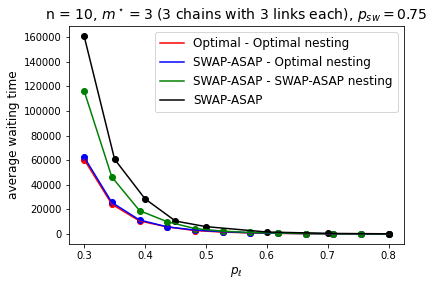

In [10]:
#3x3 concatenated

import numpy as np
import matplotlib.pyplot as plt

wt_list_global_global = np.array([60451.632, 24203.431, 10619.447,  5799.79 ,  2841.742,  1560.492,
         915.043,   552.398,   333.513,   210.075,   138.026,    90.83 ])

wt_list_global_local = np.array([62465.085, 25622.909, 11434.346,  5814.942,  3235.17 ,  1877.892,
        1048.755,   625.137,   428.021,   240.562,   158.586,   102.562])

wt_list_local_local = np.array([1.16131752e+05, 4.63126670e+04, 1.90057530e+04, 9.99414300e+03,
       4.46823200e+03, 2.32247700e+03, 1.25740200e+03, 7.53622000e+02,
       4.11411000e+02, 2.49986000e+02, 1.58114000e+02, 9.67580000e+01])

wt_SA = [160608.59, 60705.06, 28554.14, 10532.6, 6009.93, 1648.48, 499.77, 189.86]#, 56.22, 8.68]

plt.plot(np.linspace(0.3,0.8,12), wt_list_global_global,color = 'r')
plt.plot(np.linspace(0.3,0.8,12), wt_list_global_local,color = 'b')
plt.plot(np.linspace(0.3,0.8,12), wt_list_local_local,color = 'g')
plt.scatter(np.linspace(0.3,0.8,12), wt_list_global_global,color = 'r')
plt.scatter(np.linspace(0.3,0.8,12), wt_list_global_local,color = 'b')
plt.scatter(np.linspace(0.3,0.8,12), wt_list_local_local,color = 'g')
plt.plot([0.3,0.35,0.4,0.45,0.5,0.6,0.7,0.8], wt_SA, color = 'black')
plt.scatter([0.3,0.35,0.4,0.45,0.5,0.6,0.7,0.8], wt_SA, color = 'black')

plt.xlabel(r"$p_{\ell}$",fontsize=12)
plt.ylabel("average waiting time",fontsize=12)
plt.title("n = 10, $m^\star = 3$ (3 chains with 3 links each), $p_{sw}=0.75$",fontsize=14)
# plt.yscale('log')
plt.legend(["Optimal - Optimal nesting", "SWAP-ASAP - Optimal nesting", "SWAP-ASAP - SWAP-ASAP nesting", "SWAP-ASAP"],fontsize=12)
plt.savefig("concat_3x3_new.pdf")

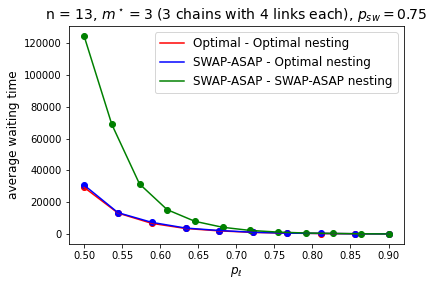

In [16]:
#3x4 concatenated

import numpy as np
import matplotlib.pyplot as plt

wt_list_global_global = np.array([29291.622, 13221.889,  6755.987,  3534.3  ,  2028.212,  1088.027,
         639.601,   371.369,   234.609,   147.054])

wt_list_global_local = np.array([30744.612, 13463.114,  7378.82 ,  3802.434,  2270.184,  1157.898,
         615.996,   422.518,   240.44 ,   162.754])

wt_list_local_local = np.array([124198.578,  68826.732,  31496.188,  15342.662,   8042.56 ,
         4304.45 ,   2306.96 ,   1284.158,    696.328,    424.202,
          223.62 ,    128.054])


plt.plot(np.linspace(0.5,0.9,10), wt_list_global_global,color = 'r')
plt.plot(np.linspace(0.5,0.9,10), wt_list_global_local,color = 'b')
plt.plot(np.linspace(0.5,0.9,12), wt_list_local_local,color = 'g')
plt.scatter(np.linspace(0.5,0.9,10), wt_list_global_global,color = 'r')
plt.scatter(np.linspace(0.5,0.9,10), wt_list_global_local,color = 'b')
plt.scatter(np.linspace(0.5,0.9,12), wt_list_local_local,color = 'g')

plt.xlabel(r"$p_{\ell}$",fontsize=12)
plt.ylabel("average waiting time",fontsize=12)
plt.title("n = 13, $m^\star = 3$ (3 chains with 4 links each), $p_{sw}=0.75$",fontsize=14)
# plt.yscale('log')
plt.legend(["Optimal - Optimal nesting", "SWAP-ASAP - Optimal nesting", "SWAP-ASAP - SWAP-ASAP nesting"],fontsize=12)
plt.savefig("concat_3x4_new.pdf")

In [ ]:
print(np.load('mean_wt_SA_opt_3_4.npy'))